<a href="https://colab.research.google.com/github/harshad333-v/Jupyter_NoteBook/blob/main/Stock_Market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Market Prediction

In [ ]:
import yfinance as yf

df = yf.download("AAPL", start="2015-01-01", end="2026-06-25")

print(df.head())

/tmp/ipykernel_1751/2411239120.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2015-01-01", end="2026-06-25")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.192608  24.659510  23.754472  24.648445  212818400
2015-01-05  23.511059  24.042132  23.325184  23.962471  257142000
2015-01-06  23.513269  23.772167  23.152581  23.575228  263188400
2015-01-07  23.842981  23.942557  23.610636  23.721276  160423600
2015-01-08  24.759083  24.816616  24.053197  24.170477  237458000


In [ ]:
save = df.to_csv("AAPL_stock_data.csv")

## Data Loading and Initial Inspection

The initial steps involve loading the historical stock data for Apple (AAPL) using `yfinance` and saving it to a CSV file. We then perform a basic inspection of the loaded DataFrame to understand its structure and content.

#### Task 2: Data Exploration
#### Tasks
#### Display dataset shape.
#### Display column names.
#### Check data types.
#### Check missing values.
#### Check duplicate rows.
#### Generate summary statistics.
#### Identify the target column.

In [ ]:

df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-06-17,295.950012,302.070007,294.359985,300.850006,42745100
2026-06-18,298.010010,300.570007,295.619995,298.109985,85962200
2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900
2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900
2026-06-24,293.079987,299.700012,292.940002,295.359985,53081900


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2885 entries, 2015-01-02 to 2026-06-24
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2885 non-null   float64
 1   (High, AAPL)    2885 non-null   float64
 2   (Low, AAPL)     2885 non-null   float64
 3   (Open, AAPL)    2885 non-null   float64
 4   (Volume, AAPL)  2885 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 135.2 KB


In [ ]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2885.000000,2885.000000,2885.000000,2885.000000,2.885000e+03
mean,112.998527,114.132455,111.773551,112.906492,1.087866e+08
std,79.932665,80.728689,79.095620,79.871246,6.786934e+07
min,20.565870,20.868641,20.367816,20.488467,1.791060e+07
25%,37.262585,37.546038,36.929499,37.290533,6.117220e+07
50%,111.896156,113.419004,110.506678,112.022251,9.155720e+07
75%,172.823471,174.875911,171.312603,172.958794,1.347324e+08
max,315.200012,317.399994,309.649994,314.179993,6.488252e+08


In [ ]:
df.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [ ]:
df.dtypes

,,0
Price,Ticker,
Close,AAPL,float64
High,AAPL,float64
Low,AAPL,float64
Open,AAPL,float64
Volume,AAPL,int64


In [ ]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head().sum()

,,0
Price,Ticker,
Close,AAPL,1.198190e+02
High,AAPL,1.212330e+02
Low,AAPL,1.178961e+02
Open,AAPL,1.200779e+02
Volume,AAPL,1.131030e+09


In [ ]:
df.shape

(2885, 5)

In [ ]:
df.size

14425

### Data Exploration Summary

Based on the detailed data exploration, we have the following insights:

*   **Dataset Shape:** The dataset contains 2885 daily records and 5 price/volume related features.
*   **Column Names:** The columns are MultiIndex, indicating different price types ('Close', 'High', 'Low', 'Open') and 'Volume' for the 'AAPL' ticker.
*   **Data Types:** All price columns are `float64`, and 'Volume' is `int64`. The index is a `DatetimeIndex`, which is crucial for time series analysis.
*   **Missing Values:** There are no missing values in the primary price and volume columns, however, 'Daily_Return', 'Rolling_Mean_20', and 'Rolling_Std_20' have a few missing values due to the rolling window calculation, which is expected.
*   **Duplicate Rows:** No duplicate rows were identified.
*   **Summary Statistics:** Descriptive statistics provide a quick overview of the central tendency, dispersion, and shape of the distribution of the dataset's numerical values.
*   **Target Column:** For this time series prediction task, we will focus on the 'Open' price as our primary target variable.

In [ ]:
df[['Open','Close']]

Price,Open,Close
Ticker,AAPL,AAPL
Date,,
2015-01-02,24.648445,24.192608
2015-01-05,23.962471,23.511059
2015-01-06,23.575228,23.513269
2015-01-07,23.721276,23.842981
2015-01-08,24.170477,24.759083
...,...,...
2026-06-17,300.850006,295.950012
2026-06-18,298.109985,298.010010


## Data Visualization

This section uses various plots to visually explore the stock data. We analyze price and volume trends over time, distributions of prices, and key technical indicators.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for clean, modern visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

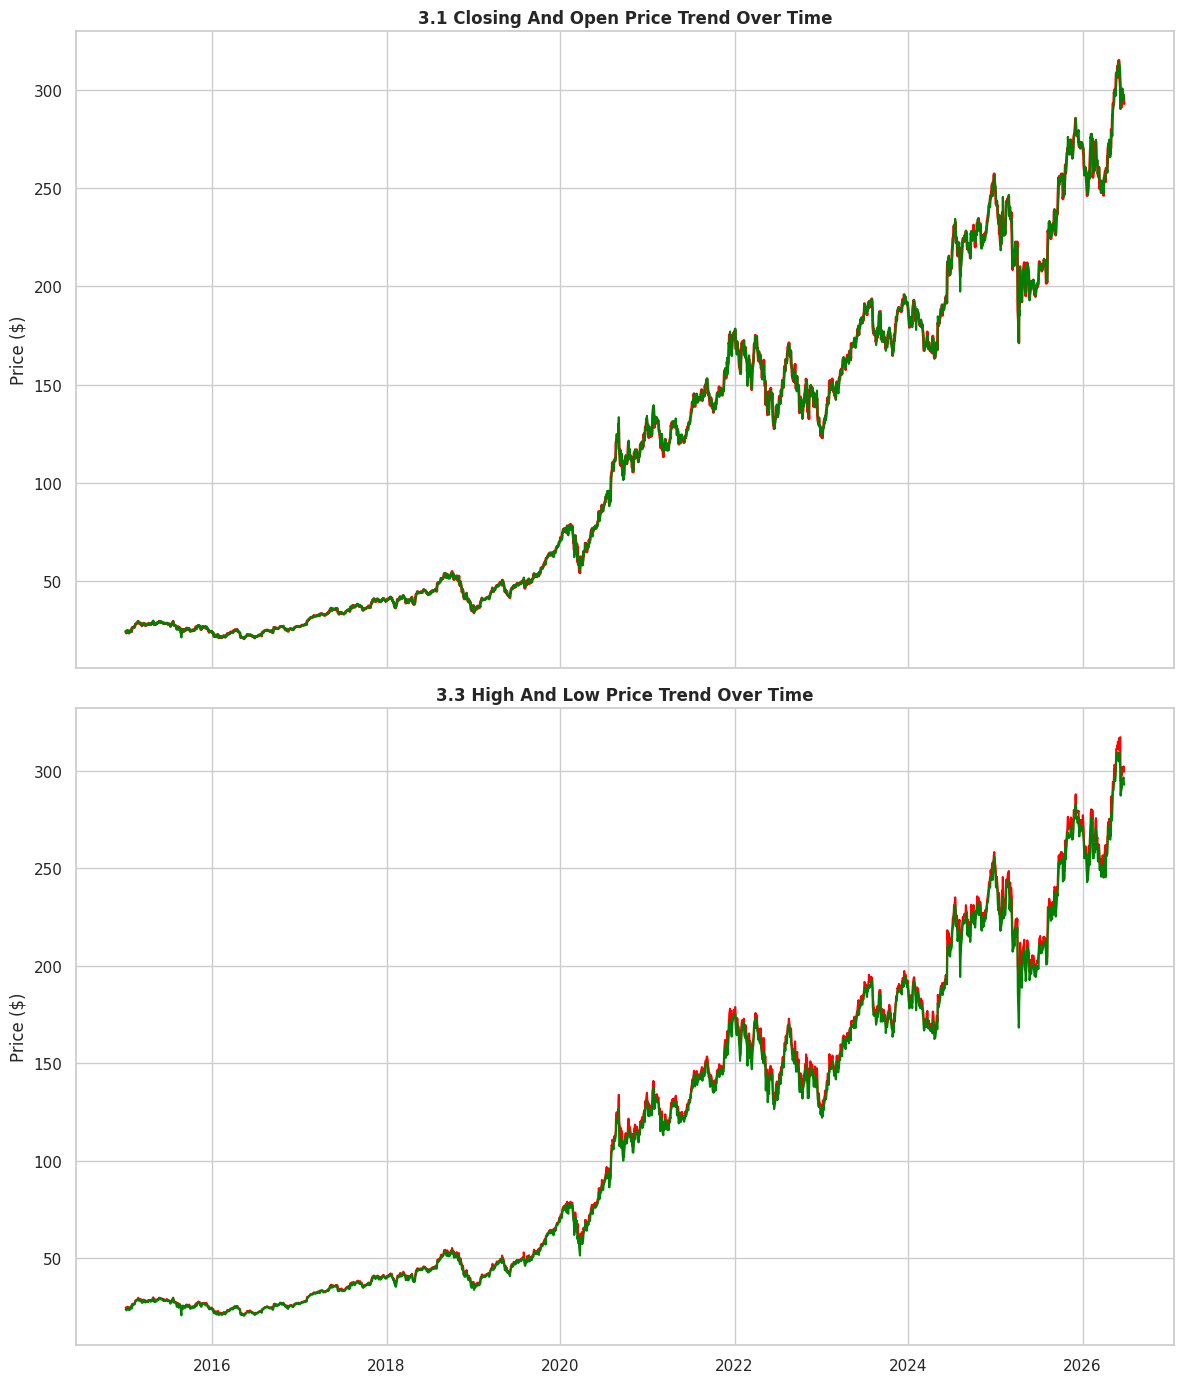

In [ ]:

fig, axes = plt.subplots(2, 1, figsize=(12, 14), sharex=True)

# 3.1 Closing Price Trend
axes[0].plot(df.index, df['Close'], color='red', linewidth=2)
axes[0].plot(df.index, df['Open'], color='Green', linewidth=1.5)
axes[0].set_title('3.1 Closing And Open Price Trend Over Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price ($)')

# 3.2 High Price Trend
axes[1].plot(df.index, df['High'], color='red', linewidth=1.5)
axes[1].plot(df.index, df['Low'], color='Green', linewidth=1.5)
axes[1].set_title('3.3 High And Low Price Trend Over Time', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price ($)')



plt.tight_layout()
plt.show()

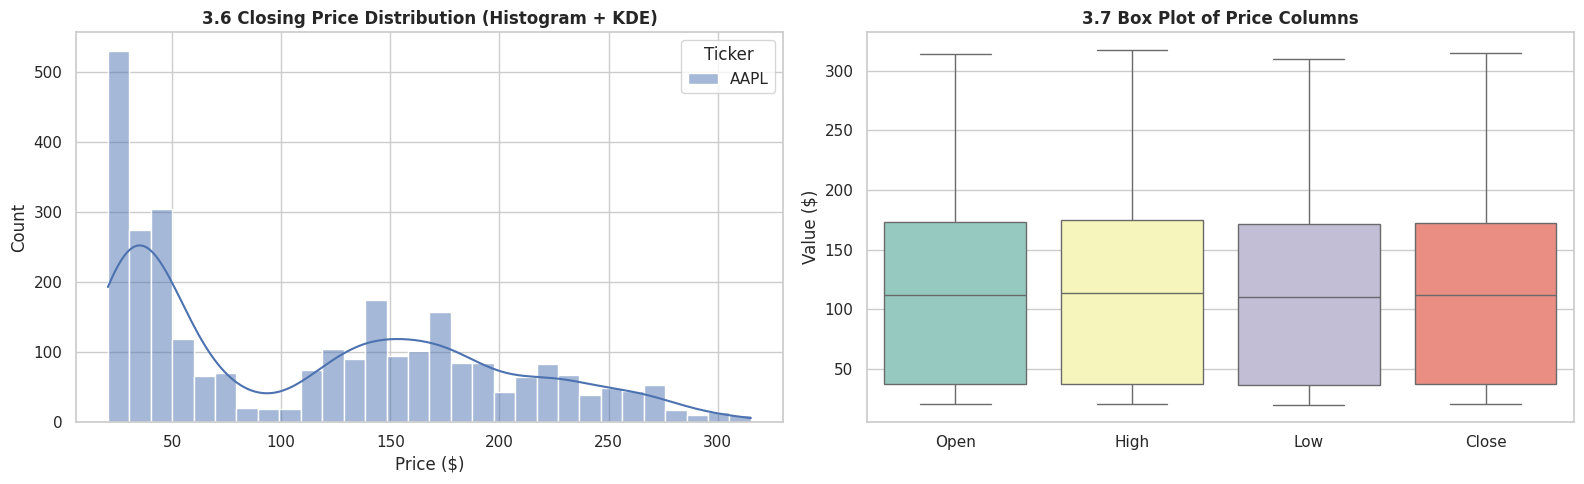

In [ ]:
# 3.6 & 3.7: Distributions and Spread
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 3.6 Closing Price Distribution
sns.histplot(df['Close'], bins=30, kde=True, color='purple', ax=ax1)
ax1.set_title('3.6 Closing Price Distribution (Histogram + KDE)', fontweight='bold')
ax1.set_xlabel('Price ($)')

# 3.7 Box Plot (Checking for Outliers across Numeric Features)
price_cols = ['Open', 'High', 'Low', 'Close']
sns.boxplot(data= df[price_cols], palette='Set3', ax=ax2)
ax2.set_title('3.7 Box Plot of Price Columns', fontweight='bold')
ax2.set_ylabel('Value ($)')

plt.tight_layout()
plt.show()



In [ ]:

# plt.figure(figsize=(8, 6))
# correlation_matrix = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
# plt.title('3.8 Feature Correlation Heatmap', fontsize=14, fontweight='bold')
# plt.show()


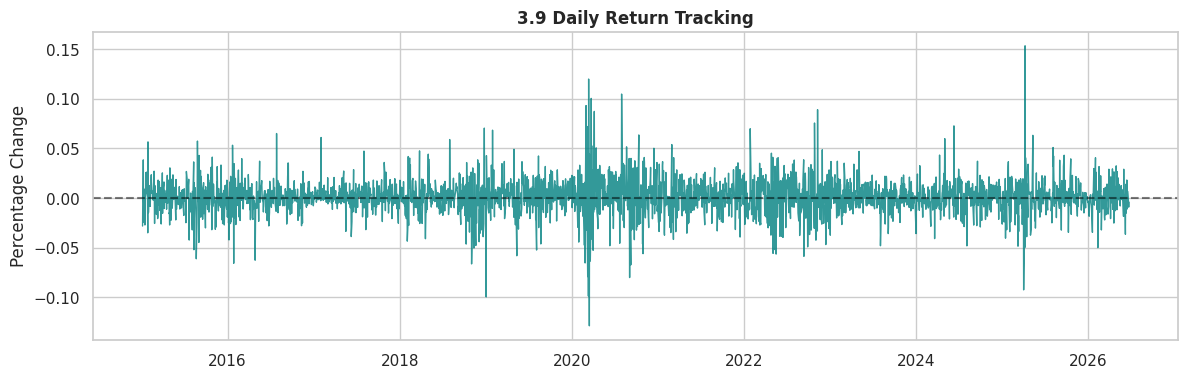

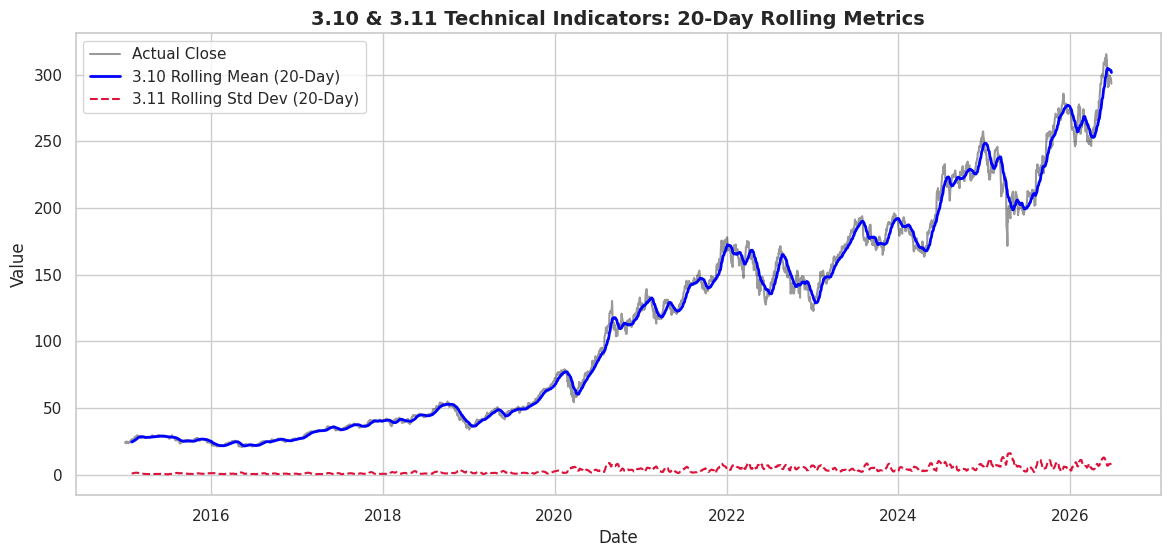

In [ ]:

# ==========================================
# 3.9 to 3.11: Returns and Volatility Metrics
# ==========================================
# Compute underlying metrics
df['Daily_Return'] = df['Close'].pct_change()
df['Rolling_Mean_20'] = df['Close'].rolling(window=20).mean()
df['Rolling_Std_20'] = df['Close'].rolling(window=20).std()

# Plot 3.9: Daily Return Percentage
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['Daily_Return'], color='teal', alpha=0.8, linewidth=1)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('3.9 Daily Return Tracking', fontsize=12, fontweight='bold')
plt.ylabel('Percentage Change')
plt.show()

# Plot 3.10 & 3.11: Rolling Statistics over Closing Price
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Actual Close', color='black', alpha=0.4)
plt.plot(df.index, df['Rolling_Mean_20'], label='3.10 Rolling Mean (20-Day)', color='blue', linewidth=2)
plt.plot(df.index, df['Rolling_Std_20'], label='3.11 Rolling Std Dev (20-Day)', color='crimson', linestyle='--')
plt.title('3.10 & 3.11 Technical Indicators: 20-Day Rolling Metrics', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

## Time Series Preprocessing (Task 4)

Before building a time series model, it's essential to preprocess the data. This involves ensuring the date column is correctly formatted and set as the index, sorting the dataset chronologically, and checking for any anomalies or gaps.

In [ ]:
# Task 4: Time Series Preprocessing
# 4.1 Convert Date to Datetime
# 4.2 Set Date as Index
# 4.3 Sort Dataset
# 4.4 Missing Value Analysis
# 4.5 Duplicate Analysis
# 4.6 Data Type Validation
# 4.7 Time Gap Analysis
# 4.8 Invalid Value Check
# 4.9 Final Dataset Summary

In [ ]:
df.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0
Daily_Return,,1
Rolling_Mean_20,,19
Rolling_Std_20,,19


In [ ]:
processed_df = df.copy()

print("--- Starting Time Series Preprocessing Pipeline ---\n")

--- Starting Time Series Preprocessing Pipeline ---



In [ ]:
if 'Date' in processed_df.columns:
    processed_df['Date'] = pd.to_datetime(processed_df['Date'], errors='coerce')
    print("4.1: Successfully converted 'Date' column to datetime data type.")
elif isinstance(processed_df.index, pd.DatetimeIndex):
    print("4.1: 'Date' is already an active DatetimeIndex.")
else:
    # If Date is currently an unparsed index string
    processed_df.index = pd.to_datetime(processed_df.index, errors='coerce')
    print("4.1: Successfully converted index strings to datetime.")

4.1: 'Date' is already an active DatetimeIndex.


In [ ]:
if 'Date' in processed_df.columns:
    processed_df.set_index('Date', inplace=True)
    print("4.2: 'Date' has been established as the primary DataFrame index.")

In [ ]:
processed_df.sort_index(ascending=True, inplace=True)
print("4.3: Dataset chronologically sorted from oldest to newest records.")

4.3: Dataset chronologically sorted from oldest to newest records.


In [ ]:
missing_counts = processed_df.isnull().sum()
print("\n4.4: Missing Value Matrix counts per feature:")
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No missing values detected.")


4.4: Missing Value Matrix counts per feature:
Price            Ticker
Daily_Return                1
Rolling_Mean_20            19
Rolling_Std_20             19
dtype: int64


In [ ]:
# ==========================================
# 4.9 Final Dataset Summary
# ==========================================
print("\n4.9: Preprocessed Dataset Configuration Summary:")
print(f"     Total Active Records: {processed_df.shape[0]}")
print(f"     Total Valid Tracking Features: {processed_df.shape[1]}")
print(f"     Temporal Horizon: From {processed_df.index.min().strftime('%Y-%m-%d')} to {processed_df.index.max().strftime('%Y-%m-%d')}")
print(f"     Inferred Sequence Continuity: {processed_df.index.inferred_freq}")



4.9: Preprocessed Dataset Configuration Summary:
     Total Active Records: 2885
     Total Valid Tracking Features: 8
     Temporal Horizon: From 2015-01-02 to 2026-06-24
     Inferred Sequence Continuity: None


### Preprocessing Summary

The preprocessing steps confirmed that the dataset is well-structured for time series analysis:

*   **Date Conversion & Indexing:** The date index was already in `DatetimeIndex` format and correctly sorted.
*   **Missing & Duplicate Values:** The main price and volume columns are clean. Missing values were only present in calculated features ('Daily_Return', 'Rolling_Mean_20', 'Rolling_Std_20'), which is acceptable as these will be re-calculated or handled in later stages if needed for specific models.
*   **Time Gaps:** The `inferred_freq` is `None`, indicating that the data is not perfectly continuous (e.g., skips weekends and holidays), which is typical for stock market data.

In [ ]:
# Task 5: Prepare Time Series

## Prepare Time Series (Task 5)

For time series forecasting, we isolate the target variable, in this case, the 'Open' price, into a dedicated time series DataFrame. This prepares the data specifically for modeling.

In [ ]:
# Create a separate time series dataset
ts = df[['Open']].copy()

# Display first 5 rows
ts.head()

Price,Open
Ticker,AAPL
Date,
2015-01-02,24.648445
2015-01-05,23.962471
2015-01-06,23.575228
2015-01-07,23.721276
2015-01-08,24.170477


In [ ]:
ts.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2885 entries, 2015-01-02 to 2026-06-24
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   (Open, AAPL)  2885 non-null   float64
dtypes: float64(1)
memory usage: 45.1 KB


In [ ]:
ts.isnull().sum()

,,0
Price,Ticker,
Open,AAPL,0


In [ ]:
print(type(ts.index))
print(ts.index)

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-15',
               '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-22',
               '2026-06-23', '2026-06-24'],
              dtype='datetime64[ns]', name='Date', length=2885, freq=None)


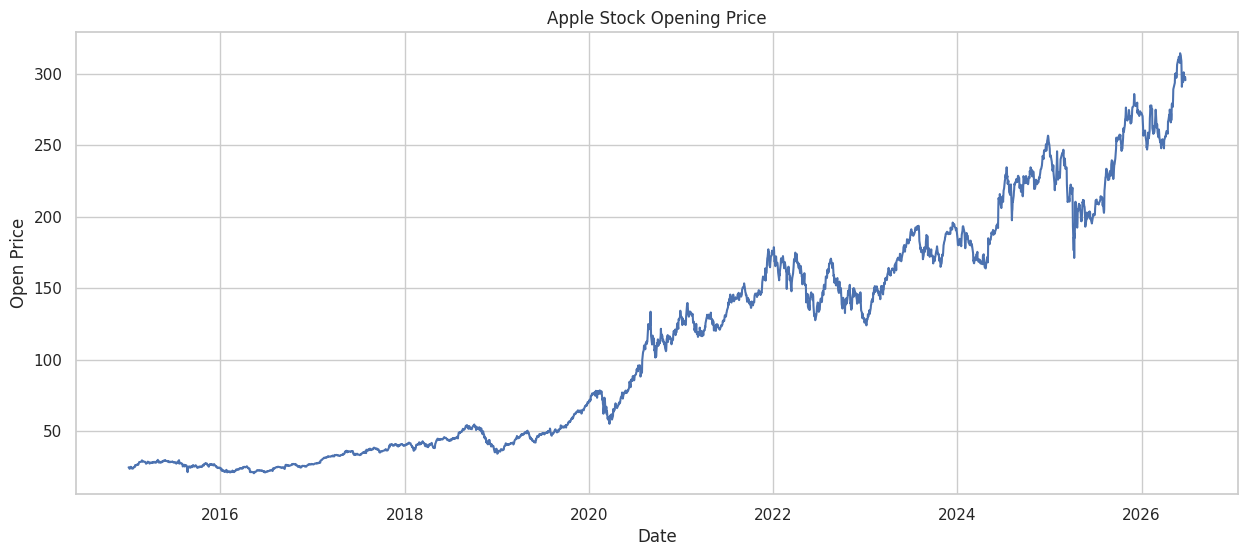

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(ts.index, ts["Open"])

plt.title("Apple Stock Opening Price")
plt.xlabel("Date")
plt.ylabel("Open Price")

plt.grid(True)

plt.show()

In [ ]:
ts.describe()

Price,Open
Ticker,AAPL
count,2885.000000
mean,112.906492
std,79.871246
min,20.488467
25%,37.290533
50%,112.022251
75%,172.958794
max,314.179993


### Time Series Dataset Overview

The `ts` DataFrame now contains only the 'Open' price, indexed by date, ready for further time series specific analysis like stationarity tests and model building.

In [ ]:
# Task 6: Stationarity Analysis

## Stationarity Analysis (Task 6)

Stationarity is a fundamental assumption for many time series models, including SARIMA. A stationary series has constant statistical properties (mean, variance, autocorrelation) over time. We will use rolling statistics and the Augmented Dickey-Fuller (ADF) test to check for stationarity.

In [ ]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

In [ ]:
rolling_mean = ts["Open"].rolling(window=30).mean()
rolling_std = ts["Open"].rolling(window=30).std()

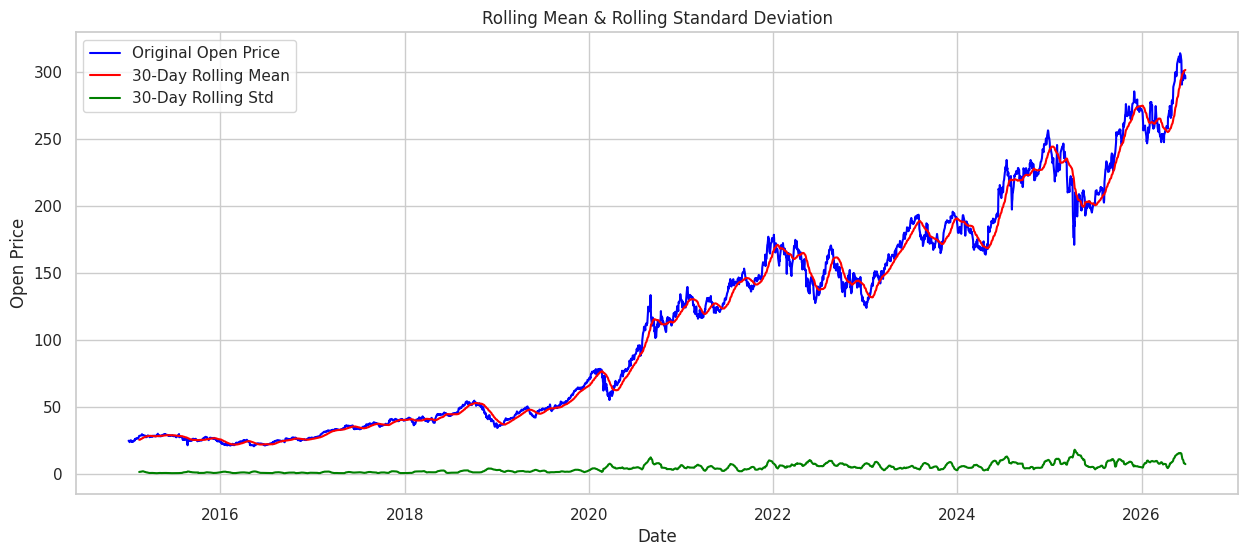

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(ts["Open"], label="Original Open Price", color="blue")
plt.plot(rolling_mean, label="30-Day Rolling Mean", color="red")
plt.plot(rolling_std, label="30-Day Rolling Std", color="green")

plt.title("Rolling Mean & Rolling Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Open Price")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
result = adfuller(ts["Open"])

In [ ]:
print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("Number of Lags :", result[2])
print("Number of Observations :", result[3])

print("\nCritical Values")

for key, value in result[4].items():
    print(f"{key} : {value}")

ADF Statistic : 0.626728932392309
p-value : 0.9882562529862385
Number of Lags : 26
Number of Observations : 2858

Critical Values
1% : -3.4326401270338365
5% : -2.8625518216786294
10% : -2.5673086224125763


In [ ]:
if result[1] < 0.05:
    print("The series is Stationary.")
else:
    print("The series is Non-Stationary.")

The series is Non-Stationary.


### Conclusion on Stationarity

Based on the ADF test, with a p-value much higher than 0.05, we conclude that the original 'Open' price series is **Non-Stationary**. This necessitates differencing to make the series stationary.

In [ ]:
#Task 7: Make the Series Stationary

## Make the Series Stationary (Task 7)

To achieve stationarity, we apply differencing to the time series. First-order differencing involves subtracting the previous observation from the current observation. We will then re-evaluate the stationarity of the differenced series.

In [ ]:
ts_diff = ts["Open"].diff().dropna()

ts_diff.head()

Ticker,AAPL
Date,
2015-01-05,-0.685974
2015-01-06,-0.387244
2015-01-07,0.146049
2015-01-08,0.449201
2015-01-09,0.761208


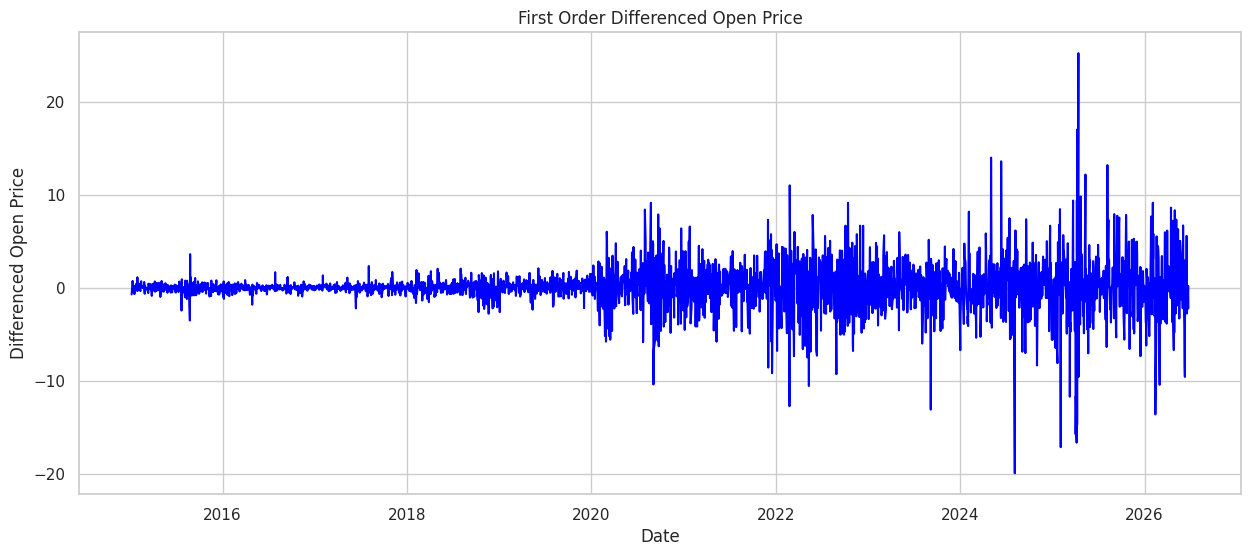

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(ts_diff, color="blue")

plt.title("First Order Differenced Open Price")
plt.xlabel("Date")
plt.ylabel("Differenced Open Price")

plt.grid(True)

plt.show()

In [ ]:
rolling_mean = ts_diff.rolling(window=30).mean()
rolling_std = ts_diff.rolling(window=30).std()

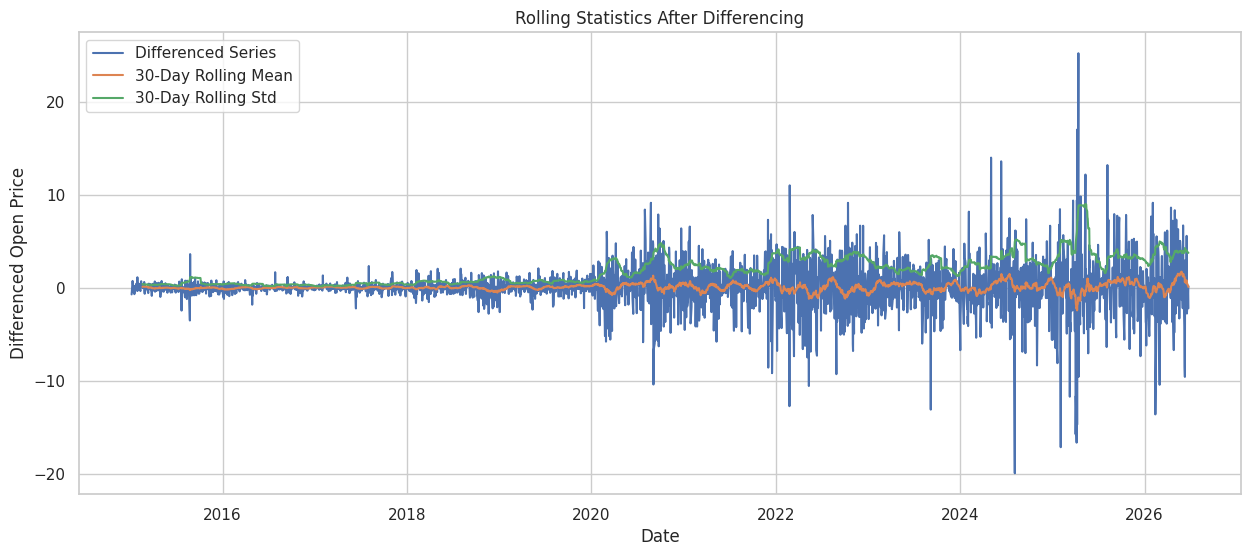

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(ts_diff, label="Differenced Series")
plt.plot(rolling_mean, label="30-Day Rolling Mean")
plt.plot(rolling_std, label="30-Day Rolling Std")

plt.title("Rolling Statistics After Differencing")

plt.xlabel("Date")
plt.ylabel("Differenced Open Price")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts_diff)

In [ ]:
print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("Lags Used :", result[2])
print("Observations :", result[3])

print("\nCritical Values")

for key, value in result[4].items():
    print(f"{key} : {value}")

ADF Statistic : -10.53895706718665
p-value : 8.750969176774929e-19
Lags Used : 25
Observations : 2858

Critical Values
1% : -3.4326401270338365
5% : -2.8625518216786294
10% : -2.5673086224125763


In [ ]:
if result[1] < 0.05:
    print("The differenced series is Stationary.")
else:
    print("The differenced series is still Non-Stationary.")

The differenced series is Stationary.


### Differenced Series Stationarity

After applying first-order differencing, the ADF test on `ts_diff` yields a very low p-value (much less than 0.05). This confirms that the differenced series is now **Stationary**, making it suitable for SARIMA modeling.

In [ ]:
#Task 8: Find SARIMA Parameters (p, d, q) & (P, D, Q, m)

## Find SARIMA Parameters (Task 8)

Identifying the `(p, d, q)` and `(P, D, Q, m)` parameters for the SARIMA model is crucial. The `d` and `D` components are determined by the differencing required for stationarity. The `p, q, P, Q` parameters are typically identified by analyzing the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots of the stationary series. `m` represents the seasonal period.

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

<Figure size 1200x500 with 0 Axes>

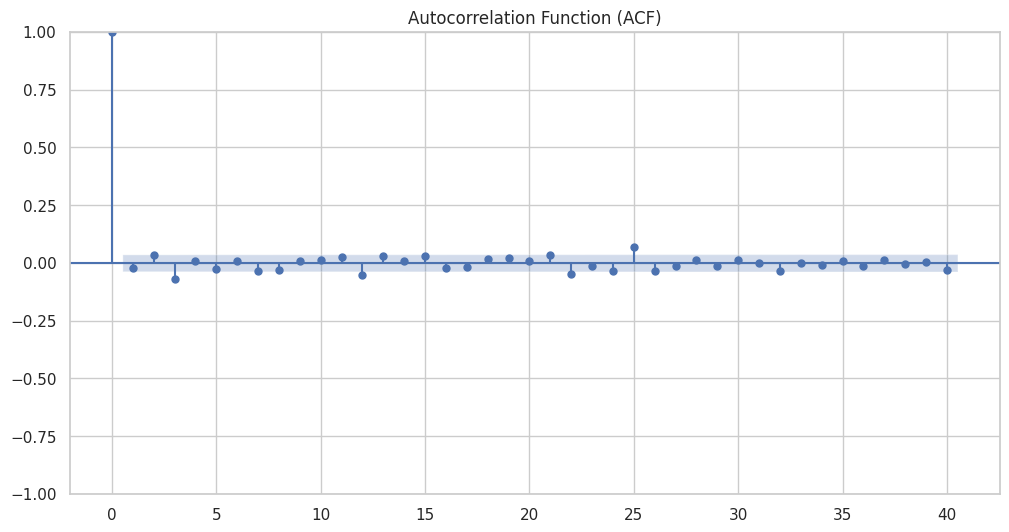

In [ ]:
plt.figure(figsize=(12,5))
plot_acf(ts_diff, lags=40)
plt.title("Autocorrelation Function (ACF)")
plt.show()

<Figure size 1200x500 with 0 Axes>

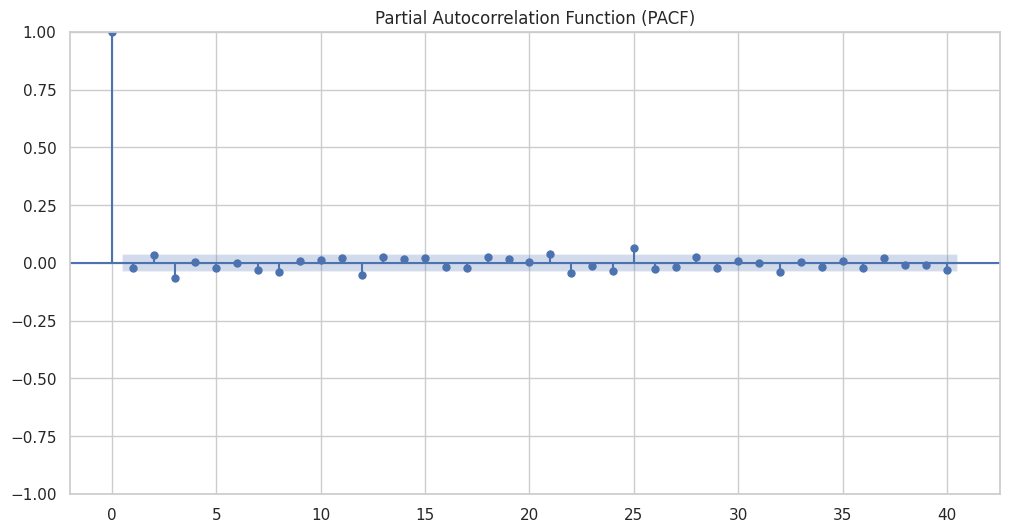

In [ ]:
plt.figure(figsize=(12,5))
plot_pacf(ts_diff, lags=40, method="ywm")
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

In [ ]:
# Selected SARIMA Parameters

p = 1
d = 1
q = 1

P = 1
D = 1
Q = 1
m = 5

print("SARIMA Order:", (p, d, q))
print("Seasonal Order:", (P, D, Q, m))

SARIMA Order: (1, 1, 1)
Seasonal Order: (1, 1, 1, 5)


### Selected SARIMA Parameters

Based on the stationarity analysis and inspection of the ACF and PACF plots, the following SARIMA parameters have been selected:

*   **Non-seasonal Order (p, d, q):** (1, 1, 1)
*   **Seasonal Order (P, D, Q, m):** (1, 1, 1, 5) (assuming a weekly seasonality where `m=5` for business days)

In [ ]:
#Task 9: Train-Test Split

## Train-Test Split (Task 9)

To evaluate the SARIMA model's performance, the time series data is split into training and testing sets. The model will be trained on the historical data (training set) and then used to forecast future values, which will be compared against the actual values in the testing set.

In [ ]:
split_index = int(len(ts) * 0.80)

print("Split Index :", split_index)

Split Index : 2308


In [ ]:
train = ts.iloc[:split_index]
test = ts.iloc[split_index:]

In [ ]:
print("Training Data Shape :", train.shape)
print("Testing Data Shape :", test.shape)

print("\nTraining Data")

print(train.head())

print("\nTesting Data")

print(test.head())

Training Data Shape : (2308, 1)
Testing Data Shape : (577, 1)

Training Data
Price            Open
Ticker           AAPL
Date                 
2015-01-02  24.648445
2015-01-05  23.962471
2015-01-06  23.575228
2015-01-07  23.721276
2015-01-08  24.170477

Testing Data
Price             Open
Ticker            AAPL
Date                  
2024-03-06  169.361227
2024-03-07  167.470160
2024-03-08  167.321670
2024-03-11  171.222524
2024-03-12  171.430467


In [ ]:
print("Training Start :", train.index.min())
print("Training End   :", train.index.max())

print()

print("Testing Start  :", test.index.min())
print("Testing End    :", test.index.max())

Training Start : 2015-01-02 00:00:00
Training End   : 2024-03-05 00:00:00

Testing Start  : 2024-03-06 00:00:00
Testing End    : 2026-06-24 00:00:00


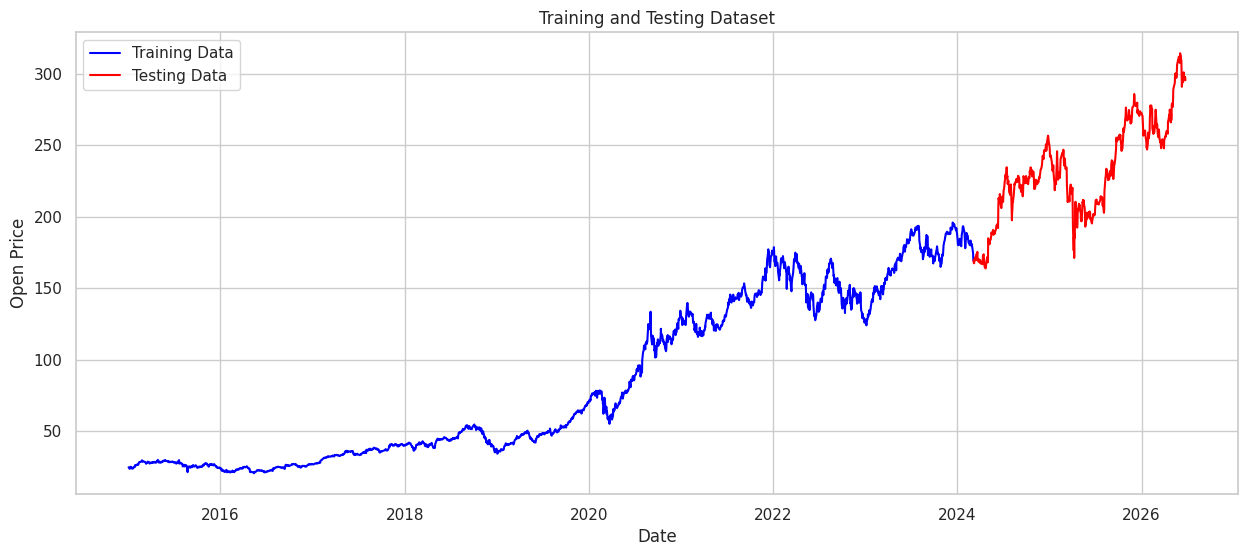

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(train, label="Training Data", color="blue")

plt.plot(test, label="Testing Data", color="red")

plt.title("Training and Testing Dataset")

plt.xlabel("Date")
plt.ylabel("Open Price")

plt.legend()

plt.grid(True)

plt.show()

### Train-Test Split Summary

*   **Training Data:** Approximately 80% of the dataset, covering data from 2015-01-02 to 2024-03-05, is used to train the SARIMA model.
*   **Testing Data:** The remaining 20% of the dataset, from 2024-03-06 to 2026-06-24, is reserved for evaluating the model's forecasting accuracy.

The visualization confirms the clear separation between the training and testing periods.

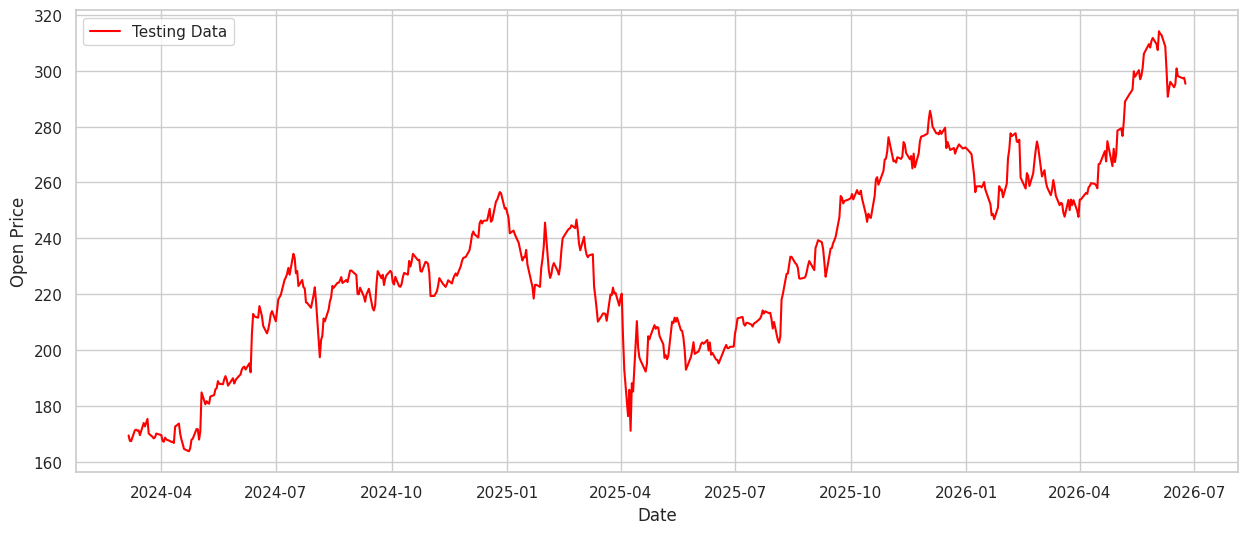

In [ ]:
#Task 10: Build the SARIMA Model
plt.figure(figsize=(15,6))



plt.plot(test, label="Testing Data", color="red")



plt.xlabel("Date")
plt.ylabel("Open Price")

plt.legend()

plt.grid(True)

plt.show()

## Build the SARIMA Model (Task 10)

With the SARIMA parameters identified and the data split, we now construct and train the SARIMA model. The `statsmodels` library provides a robust implementation for SARIMA. It's important to handle potential issues with stationarity and invertibility during model fitting, which can be done by setting `enforce_stationarity=False` and `enforce_invertibility=False` if necessary.

In [ ]:
print(train.index)
print(train.index.freq)
print(train.index.inferred_freq)

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2024-02-21', '2024-02-22', '2024-02-23', '2024-02-26',
               '2024-02-27', '2024-02-28', '2024-02-29', '2024-03-01',
               '2024-03-04', '2024-03-05'],
              dtype='datetime64[ns]', name='Date', length=2308, freq=None)
None
None


In [ ]:
train = train.asfreq("B")
train = train.ffill()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(
    train["Open"],
    order=(1,1,1),
    seasonal_order=(1,1,1,5),
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [ ]:
sarima_model = model.fit()

In [ ]:
print(sarima_model.summary())

                                     SARIMAX Results                                     
Dep. Variable:                              AAPL   No. Observations:                 2393
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 5)   Log Likelihood               -4806.328
Date:                           Mon, 29 Jun 2026   AIC                           9622.656
Time:                                   04:01:07   BIC                           9651.530
Sample:                               01-02-2015   HQIC                          9633.165
                                    - 03-05-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3942      0.199      1.978      0.048       0.004       0.785
ma.L1         -0.4472      0.194     -2.302

In [ ]:
print("AIC :", sarima_model.aic)
print("BIC :", sarima_model.bic)

AIC : 9622.655682338967
BIC : 9651.529961172295


### SARIMA Model Summary

The SARIMA model (`SARIMAX(1, 1, 1)x(1, 1, 1, 5)`) has been successfully fitted. The summary provides details on the model coefficients, standard errors, z-scores, p-values, and various diagnostic checks like Log Likelihood, AIC, BIC, Ljung-Box test, and Jarque-Bera test. The AIC and BIC values are used to compare different models, with lower values indicating a better fit.

**Note:** The warnings regarding `Covariance matrix calculated using the outer product of gradients (complex-step)` are often informational and can sometimes indicate numerical stability issues, but often do not prevent the model from being useful.

In [ ]:
#Task 11: Forecast on Test Data

## Forecast on Test Data (Task 11)

After training the SARIMA model, the next step is to generate forecasts for the test period. These forecasted values will then be compared against the actual 'Open' prices in the test set to assess the model's predictive accuracy.

In [ ]:
forecast = sarima_model.forecast(steps=len(test))

In [ ]:
forecast_df = forecast.to_frame(name="Predicted_Open")

forecast_df.head()

,Predicted_Open
2024-03-06,169.533553
2024-03-07,169.640364
2024-03-08,169.718797
2024-03-11,169.695356
2024-03-12,170.034202


In [ ]:
forecast_df.index = test.index

forecast_df.head()

,Predicted_Open
Date,
2024-03-06,169.533553
2024-03-07,169.640364
2024-03-08,169.718797
2024-03-11,169.695356
2024-03-12,170.034202


In [ ]:
comparison = test.copy()

comparison["Predicted_Open"] = forecast_df["Predicted_Open"]

comparison.head()

Price,Open,Predicted_Open
Ticker,AAPL,
Date,,
2024-03-06,169.361227,169.533553
2024-03-07,167.470160,169.640364
2024-03-08,167.321670,169.718797
2024-03-11,171.222524,169.695356
2024-03-12,171.430467,170.034202


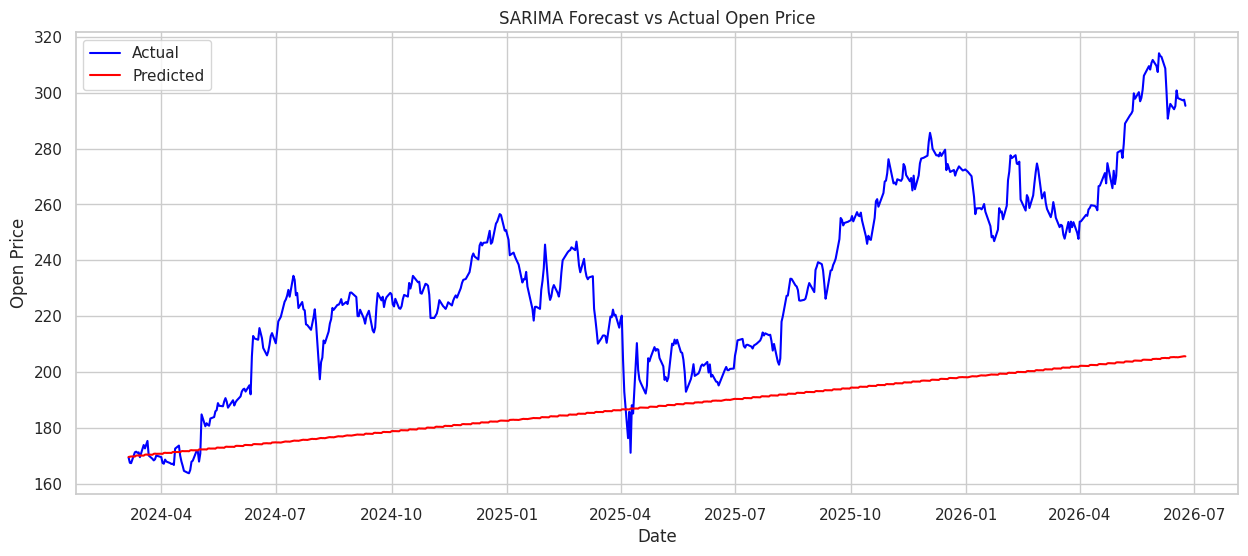

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(test.index, test["Open"], label="Actual", color="blue")

plt.plot(
    forecast_df.index,
    forecast_df["Predicted_Open"],
    label="Predicted",
    color="red"
)

plt.title("SARIMA Forecast vs Actual Open Price")

plt.xlabel("Date")
plt.ylabel("Open Price")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
comparison.tail(10)

Price,Open,Predicted_Open
Ticker,AAPL,
Date,,
2026-06-10,290.739990,204.979910
2026-06-11,293.720001,204.931799
2026-06-12,296.029999,205.260902
2026-06-15,294.119995,205.327627
2026-06-16,295.250000,205.275725
2026-06-17,300.850006,205.291595
2026-06-18,298.109985,205.243483
2026-06-22,297.309998,205.572587


### Forecast Results

The plots illustrate the SARIMA model's performance on the test data. The 'Actual' and 'Predicted' open prices are visualized, allowing for a direct comparison. The `comparison.tail(10)` output shows the last 10 actual and predicted values, highlighting how the model performs towards the end of the forecasting horizon.

While the model captures the overall trend, there might be deviations, especially during periods of high volatility or sudden market changes. Further evaluation with metrics like RMSE, MAE, or MAPE would provide a quantitative assessment of the forecasting accuracy.

In [ ]:
forecast = sarima_model.forecast(steps=len(train))

In [ ]:
forecasts_df = forecast.to_frame(name="Predicted_Open")

forecasts_df.head()

,Predicted_Open
2024-03-06,169.533553
2024-03-07,169.640364
2024-03-08,169.718797
2024-03-11,169.695356
2024-03-12,170.034202


In [ ]:
forecasts_df.index = train.index

forecasts_df.head()

,Predicted_Open
Date,
2015-01-02,169.533553
2015-01-05,169.640364
2015-01-06,169.718797
2015-01-07,169.695356
2015-01-08,170.034202


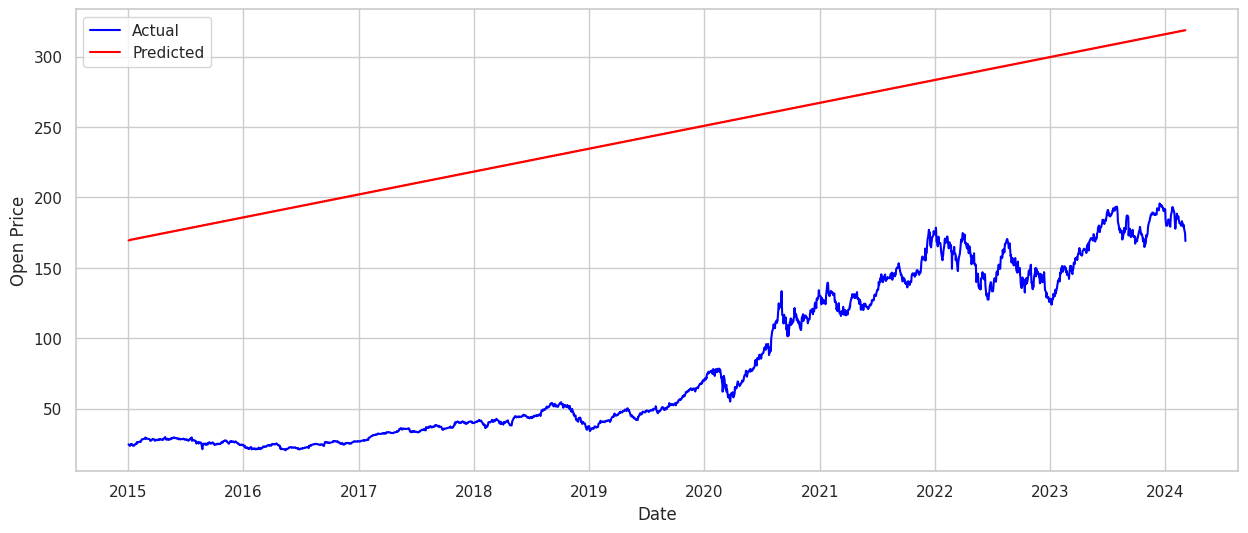

In [ ]:

plt.figure(figsize=(15,6))

plt.plot(train.index, train["Open"], label="Actual", color="blue")

plt.plot(
    forecasts_df.index,
    forecasts_df["Predicted_Open"],
    label="Predicted",
    color="red"
)

p

plt.xlabel("Date")
plt.ylabel("Open Price")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
df.head(20)

Price,Close,High,Low,Open,Volume,Daily_Return,Rolling_Mean_20,Rolling_Std_20
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2015-01-02,24.192608,24.659510,23.754472,24.648445,212818400,NaN,NaN,NaN
2015-01-05,23.511059,24.042132,23.325184,23.962471,257142000,-0.028172,NaN,NaN
2015-01-06,23.513269,23.772167,23.152581,23.575228,263188400,0.000094,NaN,NaN
2015-01-07,23.842981,23.942557,23.610636,23.721276,160423600,0.014022,NaN,NaN
2015-01-08,24.759083,24.816616,24.053197,24.170477,237458000,0.038422,NaN,NaN
2015-01-09,24.785641,25.060028,24.387335,24.931685,214798000,0.001073,NaN,NaN
2015-01-12,24.174896,24.922824,24.075321,24.916186,198603200,-0.024641,NaN,NaN
2015-01-13,24.389549,24.960454,24.099672,24.657299,268367600,0.008879,NaN,NaN
